In [1]:
from torch import nn as nn
import torch
import torch.autograd as ag
import numpy as np
import matplotlib.pyplot as plt

In [2]:

#initial
TI0 = 31.5
TD0 = 16.2
TNI0 = 1.26
Integral_Zp = 0.0
L_scale = 1e9
L0 = 2.71E9/L_scale

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TD_value = torch.tensor([TD0], dtype=torch.float32, device=device)
TI_value = (torch.tensor([TI0], dtype=torch.float32, device=device))
TN_value = (torch.tensor([TNI0], dtype=torch.float32, device=device))
L_value = (torch.tensor([L0], dtype=torch.float32, device=device))
Integral_Zp = (torch.tensor([Integral_Zp], dtype=torch.float32, device=device))

#Parameters
K = 1000
mu = 0.1
p1 = 1
p2 = 20
KL = 2E10/L_scale
s = 1.5E8/L_scale
delta_D = 0.2
delta_L = 0.033
D = 240
lamda = 0.1
kappa = 0.01
omega = 0.007
gamma = 0.03
r = 5
cCTLA4 = 2
PD1 = 2
cL = 1E8/L_scale


In [3]:
n_pl = 1
n_l - 0.1
e_pl = 0.5
e_2pl  = 0.05

NameError: name 'n_l' is not defined

In [ ]:
#Building Neural Network Model
#base class for all neural network modules
class PINNModel(nn.Module):
    #constructor that takes in the parameters for the model
    def __init__(self, input_size: int = 1, output_size: int = 5, hidden_layers: int = 5, hidden_nodes: int = 64):
        super().__init__()
        #connecting the layers using nn.Linear(input,output)
        self.inputs = nn.Linear(input_size, hidden_nodes)
        self.model = nn.ModuleList([nn.Linear(hidden_nodes, hidden_nodes) for _ in range(hidden_layers)]) #creates list of these layers to iterate through
        self.outputs = nn.Linear(hidden_nodes, output_size)

        self.activation = nn.Tanh() # makes it nonlinear

    #applies activation to all layers in the model
    def _apply_model(self,x: torch.Tensor):
        for layer in self.model:
            x = self.activation(layer(x))
        return x

    #This is the prediction function
    def forward(self, t: torch.Tensor):
        t = t / 100.0
        t = self.activation(self.inputs(t))
        t = self._apply_model(t)
        t = self.outputs(t)
        return t


In [ ]:
#Preparing Points for Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 100, 1000).reshape(-1, 1) #many data points

#creating points for physics loss
x_physics = torch.linspace(0, 100, 1000, requires_grad=True, device=device, dtype=torch.float32).reshape(-1, 1)

In [ ]:
def fractionation(x):
    TI_initial = TI_value
    TD_initial = TD_value
    L_initial = L_value
    TI_value = TI_initial - (pT * TI_initial * (1 - SF_D))
    TD_value = TD_initial + (pT * TI_initial * (1 - SF_D))
    L_value = L_initial - (pT * L_initial * (1 - SF_D))

In [ ]:
#Training Loop
#Goals: Match the data points and satisfy the differential equation
Epochs = 20000
Length = 1e-3

model = PINNModel().to(device) #create neural network
optimize = torch.optim.Adam(model.parameters(), lr=1e-3) #optimizer for the model parameters


#data_loss = nn.MSELoss()

#for loop that trains the model
for epoch in range(Epochs):
    optimize.zero_grad() #reset the gradient to 0 at the start of each loop
    
    #data loss
    # y_pred = model(x_data_t) #generates prediction
    # TD_pred = y_pred[:, 0:1] #extracts the first column of the prediction
    # TI_pred = y_pred[:, 1:2] #extracts the second column of the prediction
    #loss_data = data_loss(TD_pred, y_data_t[:, 0:1]) + data_loss(TI_pred, y_data_t[:, 1:2]) #compares prediction to the data points and calculates the loss

    prediction = model(x_physics) #generates prediction for physics points
    TD_physics = (prediction[:, 0:1])
    TI_physics = (prediction[:, 1:2])
    TNI_physics = (prediction[:, 2:3])
    L_physics = (prediction[:, 3:4])
    Integral_Zp_physics = (prediction[:, 4:5])


    T = TI_physics + TD_physics + TNI_physics
    T_safe = torch.clamp(T, min=1e-8)
    Zp = (omega * (L_physics / cL)) / (1 + ((kappa * (T_safe ** (2/3)) * (L_physics / cL)) / (1 + PD1)))
    Zs = (gamma * ((1 + cCTLA4)/(r + cCTLA4))) * Integral_Zp_physics#create another differential equation and solve it for the integration

    #TD loss
    #prediction = model(x_physics) #generates prediction for physics points
    #TD_physics = prediction[:, 0:1]
    dTD = ag.grad(TD_physics, x_physics, grad_outputs=torch.ones_like(TD_physics), create_graph=True)[0]  # calculates derivative
    Residual_TD = dTD + delta_D * TD_physics #calculates physics loss

    #TI Loss
    #TI_physics = prediction[:, 1:2] #generates prediction for physics points
    dTI = ag.grad(TI_physics, x_physics, grad_outputs=torch.ones_like(TI_physics), create_graph=True)[0]  # calculates derivative
    Residual_TI = dTI - (mu * TI_physics * (1 - ((TI_physics + TD_physics)/K)) - (Zp * TI_physics) - (Zs * TI_physics)) #calculates physics loss

    # #TNI Loss
    #TNI_physics = prediction[:, 2:3]
    dTNI = ag.grad(TNI_physics, x_physics, grad_outputs=torch.ones_like(TNI_physics), create_graph=True)[0]
    Residual_TNI = dTNI - ((mu * TNI_physics) * (1 - (TNI_physics/K)) - (Zp * TNI_physics) - (Zs * TNI_physics))


    #L Loss
    #L_physics = prediction[:, 3:4]
    dL = ag.grad(L_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
    Residual_L = dL - (lamda * (((p1 * (TI_physics + TNI_physics))/(K + TI_physics + TNI_physics)) + ((p2 * TD_physics)/(K + TD_physics))) * (L_physics) * (1 - (L_physics/KL)) + s - ((delta_L) * (L_physics)))
    #Residual_L = Residual_L*L_scale

    #Zs Loss
    dG = ag.grad(Integral_Zp_physics, x_physics, torch.ones_like(Integral_Zp_physics), create_graph=True)[0]
    Residual_G = dG - Zp

    # #nPL Loss
    # nPL_physics = prediction[:, 4:5]
    # dnPL = ag.grad(nPL_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
    # Residual_nPL = dnPL - ((nPL_physics) * (D) - (ePL) * (nPL_physics) - (e2PL) * (nPL_physics)**2)
    # loss_nPL = torch.mean(Residual_nPL**2) #calculates mean squared error for physics loss


    # #nL Loss
    # nL_physics = prediction[:, 5:6]
    # dnL = ag.grad(nL_physics, x_physics, torch.ones_like(L_physics),create_graph=True)[0]
    # Residual_nL = dnL - (((nL_physics) * (D) + (e2PL * (nPL_physics)**2)))
    # loss_nL = torch.mean(Residual_nL**2) #calculates mean squared error for physics loss

    loss_TD  = torch.mean((Residual_TD)**2)
    loss_TI  = torch.mean((Residual_TI)**2)
    loss_TNI = torch.mean((Residual_TNI)**2)
    loss_L  = torch.mean((Residual_L)**2)
    loss_Zs = torch.mean(Residual_G**2)

    #adding initial loss
    initial = model(torch.tensor([[0.0]], device=device, dtype=torch.float32)) #prediction at initial condition
    TI0_pred = initial[:, 1:2] 
    TD0_pred = initial[:, 0:1] 
    TNI0_pred = initial[:, 2:3] 
    L0_pred = initial[:, 3:4]
    Integral_Zp0_pred = initial[:, 4:5]
    
    initial_loss = (
    ((TD0_pred  - TD0))**2 +
    ((TI0_pred  - TI0))**2 +
    ((TNI0_pred - TNI0))**2 +
    ((L0_pred - L0))**2 +
    ((Integral_Zp0_pred - Integral_Zp))**2
    ).mean()


    loss_physics = loss_TD + loss_TI + loss_TNI + loss_L #+ loss_nPL + loss_nL
    total_loss = loss_TD + (5 * loss_TI) + (5 * loss_TNI) + (5 * loss_L) + loss_Zs + (100 * initial_loss)

    total_loss = total_loss.mean()  # ensure scalar loss before backprop
    total_loss.backward()  # figures out what weights caused the error
    optimize.step() #fixes the model slightly to minimize error
    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Total Loss: {total_loss.item()}, Physics Loss: {loss_physics.item()}, Initial Loss: {initial_loss.item()}")

Epoch: 0, Total Loss: 126200.8828125, Physics Loss: 0.024536743760108948, Initial Loss: 1262.0076904296875
Epoch: 1000, Total Loss: 13.750152587890625, Physics Loss: 10.590672492980957, Initial Loss: 0.02744884416460991
Epoch: 2000, Total Loss: 11.030542373657227, Physics Loss: 10.592427253723145, Initial Loss: 0.00016417258302681148
Epoch: 3000, Total Loss: 11.029756546020508, Physics Loss: 10.593022346496582, Initial Loss: 0.000126293656649068
Epoch: 4000, Total Loss: 11.029854774475098, Physics Loss: 10.592815399169922, Initial Loss: 0.000137090974021703
Epoch: 5000, Total Loss: 11.024840354919434, Physics Loss: 10.55383586883545, Initial Loss: 0.00029663325403817
Epoch: 6000, Total Loss: 0.58985435962677, Physics Loss: 0.3775254189968109, Initial Loss: 2.0866153136012144e-05
Epoch: 7000, Total Loss: 0.476786345243454, Physics Loss: 0.2881505787372589, Initial Loss: 0.00010053358710138127
Epoch: 8000, Total Loss: 0.4541986882686615, Physics Loss: 0.2667751908302307, Initial Loss: 0.

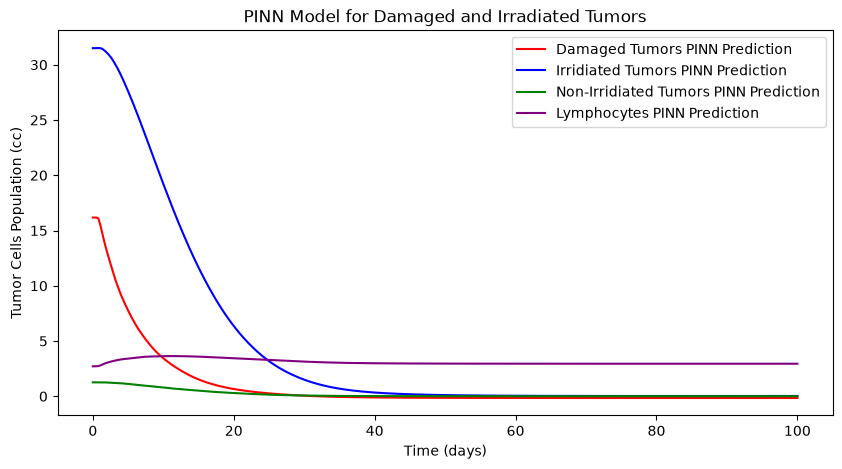

In [ ]:
#Testing the Model
model.eval()
x_test = x.detach().clone().to(device=device, dtype=torch.float32)
y_pred = model(x_test).detach().cpu().numpy()#get Pinn Solution curve
TD_pred = y_pred[:, 0]   # Extract the first column for TD predictions
TI_pred = y_pred[:, 1]  # Extract the second column for TI predictions
TNI_pred = y_pred[:, 2]  # Extract the third column for TNI predictions
L_pred = y_pred[:, 3] # Extract the fourth column for L predictions

#Plotting the Neural Network Model vs Analytical Solution
plt.figure(figsize=(10, 5))
plt.title("PINN Model for Damaged and Irradiated Tumors")
plt.xlabel("Time (days)")
plt.ylabel("Tumor Cells Population (cc)")


plt.plot(x.cpu().numpy(), TD_pred, label="Damaged Tumors PINN Prediction", color="red")
plt.plot(x.cpu().numpy(), TI_pred, label="Irridiated Tumors PINN Prediction", color="blue")
plt.plot(x.cpu().numpy(), TNI_pred, label="Non-Irridiated Tumors PINN Prediction", color="green")
plt.plot(x.cpu().numpy(), L_pred, label="Lymphocytes PINN Prediction", color="purple")

plt.legend()
plt.show()